## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")


## 2. Load Titanic Dataset

This notebook uses the Titanic dataset from Seaborn.

If the dataset does not load in your environment, install seaborn first:

```python
pip install seaborn
```


In [2]:
import seaborn as sns

df = sns.load_dataset("titanic")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Select Features and Prepare Data

Features used:

- `sex`
- `pclass`
- `age`
- `sibsp`
- `parch`

Target:

- `survived`


In [3]:
data = df[["survived", "sex", "pclass", "age", "sibsp", "parch"]].copy()

# Fill missing Age values using median
data["age"] = data["age"].fillna(data["age"].median())

# Encode Sex: male = 1, female = 0
data["sex"] = data["sex"].map({"male": 1, "female": 0})

data.head()


,survived,sex,pclass,age,sibsp,parch
0,0,1,3,22.0,1,0
1,1,0,1,38.0,1,0
2,1,0,3,26.0,0,0
3,1,0,1,35.0,1,0
4,0,1,3,35.0,0,0


In [4]:
X = data[["sex", "pclass", "age", "sibsp", "parch"]]
y = data["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 712
Testing rows: 179


## 4. Task 1: Random Forest vs Single Decision Tree

Here we compare:

1. An unrestricted Decision Tree
2. A default Random Forest

The goal is to see whether Random Forest reduces overfitting.


In [5]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)
dt_gap = dt_train_acc - dt_test_acc

print("Decision Tree Train Accuracy:", round(dt_train_acc, 3))
print("Decision Tree Test Accuracy:", round(dt_test_acc, 3))
print("Decision Tree Overfit Gap:", round(dt_gap, 3))


Decision Tree Train Accuracy: 0.917
Decision Tree Test Accuracy: 0.76
Decision Tree Overfit Gap: 0.157


In [6]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
rf_gap = rf_train_acc - rf_test_acc

print("Random Forest Train Accuracy:", round(rf_train_acc, 3))
print("Random Forest Test Accuracy:", round(rf_test_acc, 3))
print("Random Forest Overfit Gap:", round(rf_gap, 3))


Random Forest Train Accuracy: 0.917
Random Forest Test Accuracy: 0.816
Random Forest Overfit Gap: 0.101


In [7]:
comparison_df = pd.DataFrame({
    "Model": ["Unrestricted Decision Tree", "Random Forest"],
    "Train Accuracy": [dt_train_acc, rf_train_acc],
    "Test Accuracy": [dt_test_acc, rf_test_acc],
    "Overfit Gap": [dt_gap, rf_gap]
})

comparison_df


,Model,Train Accuracy,Test Accuracy,Overfit Gap
0,Unrestricted Decision Tree,0.917135,0.759777,0.157358
1,Random Forest,0.917135,0.815642,0.101492


### Task 1 Takeaway

The unrestricted Decision Tree usually overfits because it memorizes training patterns.

Random Forest reduces this problem by averaging predictions from many decorrelated trees.

Even if both models get similar training accuracy, Random Forest generally performs better on test data because it reduces variance.


## 5. Task 2: OOB Error vs Number of Trees

Here we train Random Forest models with different values of `n_estimators`.

For each model:

```python
OOB Error = 1 - model.oob_score_
```

This helps us find where adding more trees stops giving meaningful improvement.


In [8]:
n_values = [10, 20, 50, 100, 200, 300, 500]

oob_scores = []
oob_errors = []

for n in n_values:
    model = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        bootstrap=True,
        random_state=42
    )
    model.fit(X_train, y_train)

    oob_scores.append(model.oob_score_)
    oob_errors.append(1 - model.oob_score_)

oob_df = pd.DataFrame({
    "n_estimators": n_values,
    "OOB Score": oob_scores,
    "OOB Error": oob_errors
})

oob_df


,n_estimators,OOB Score,OOB Error
0,10,0.792135,0.207865
1,20,0.796348,0.203652
2,50,0.800562,0.199438
3,100,0.800562,0.199438
4,200,0.806180,0.193820
5,300,0.803371,0.196629
6,500,0.803371,0.196629


### Plot OOB Error Using Index Positions

Using index positions makes the graph easier to read because the x-axis values are evenly spaced.

The actual `n_estimators` values are still shown as labels.


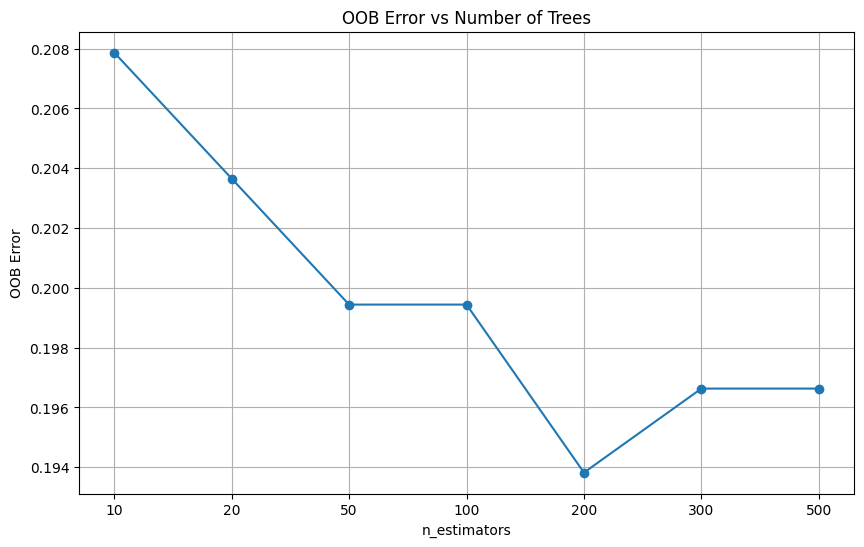

In [9]:
x_pos = range(len(n_values))

plt.figure(figsize=(10, 6))
plt.plot(x_pos, oob_errors, marker="o")

plt.xticks(x_pos, n_values)
plt.xlabel("n_estimators")
plt.ylabel("OOB Error")
plt.title("OOB Error vs Number of Trees")
plt.grid(True)
plt.show()


### Task 2 Takeaway

The OOB error may fluctuate when the number of trees is small because each training row has fewer OOB voters.

After around **200 trees**, the OOB error usually becomes stable.

Adding more trees beyond this point may increase computation time without giving meaningful performance improvement.


## 6. Task 3: Feature Importances

Now we train a Random Forest with 200 trees and compare feature importances.


In [10]:
rf_200 = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_200.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_200.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df


,Feature,Importance
2,age,0.390604
0,sex,0.352670
1,pclass,0.136394
3,sibsp,0.071062
4,parch,0.049270


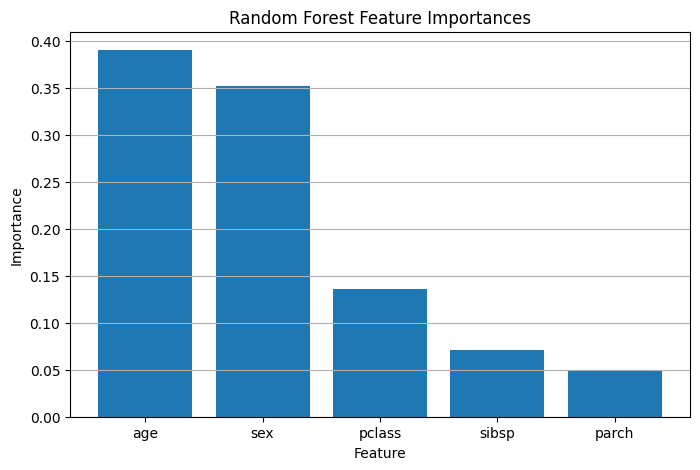

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importances")
plt.grid(axis="y")
plt.show()


### Task 3 Takeaway

In a single Decision Tree, one feature such as `sex` may dominate because all features are always available.

In Random Forest, only a random subset of features is available at each split.

Because of this, another strong feature like `age` can get more chances to contribute.

This makes Random Forest feature importance more balanced and reliable.


## 7. Task 4: Compare `max_features='sqrt'` and `max_features='log2'`

For classification, Random Forest commonly uses:

```python
max_features='sqrt'
```

Here we compare it with:

```python
max_features='log2'
```


In [12]:
max_feature_results = []

for mf in ["sqrt", "log2"]:
    model = RandomForestClassifier(
        n_estimators=200,
        max_features=mf,
        oob_score=True,
        bootstrap=True,
        random_state=42
    )
    model.fit(X_train, y_train)

    max_feature_results.append({
        "max_features": mf,
        "OOB Score": model.oob_score_,
        "OOB Error": 1 - model.oob_score_
    })

max_features_df = pd.DataFrame(max_feature_results)
max_features_df


,max_features,OOB Score,OOB Error
0,sqrt,0.80618,0.19382
1,log2,0.80618,0.19382


### Why `sqrt` and `log2` Can Give the Same Result

This dataset uses 5 features.

For 5 features:

\[
\sqrt{5} \approx 2.24 \rightarrow 2
\]

\[
\log_2(5) \approx 2.32 \rightarrow 2
\]

So both settings select **2 features per split**.

Because both choose the same number of features and use the same `random_state`, they can produce identical or nearly identical results.


### When Does `sqrt` vs `log2` Matter?

The difference matters when both settings produce different feature counts.

Example with 100 features:

```python
sqrt(100) = 10
log2(100) ≈ 6
```

Now each split considers a different number of features, so the models may behave differently.


## 8. Final Summary

Random Forest improves over a single Decision Tree because it combines two important ideas:

1. **Bagging**  
   Many trees are trained on different bootstrap samples.

2. **Random Feature Subsampling**  
   Each split considers only a random subset of features.

Together, these reduce overfitting and create a more stable model.

### Key Learnings

- Bagging reduces variance.
- OOB score gives free validation.
- More trees stabilize OOB error.
- Random Forest feature importance is more reliable than a single tree.
- `sqrt` and `log2` may behave the same on small feature sets.
